In [ ]:
# Advanced Analytics & Risk Metrics

## Bluestock Mutual Fund Analytics Platform

Day 6 Deliverables:
- Historical VaR & CVaR
- Rolling 90-Day Sharpe Ratio
- Investor Cohort Analysis
- SIP Continuity Analysis
- Fund Recommender
- Sector HHI Concentration
- Advanced Insights

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
nav_df = pd.read_csv("../data/processed/cleaned_nav_history.csv")
txn_df = pd.read_csv("../data/processed/cleaned_investor_transactions.csv")
perf_df = pd.read_csv("../data/processed/cleaned_scheme_performance.csv")

print(nav_df.shape)
print(txn_df.shape)
print(perf_df.shape)

(46000, 3)
(32778, 13)
(40, 19)


In [4]:
## Historical VaR (95%) and CVaR
# Sort by fund and date
nav_df['date'] = pd.to_datetime(nav_df['date'])
nav_df = nav_df.sort_values(['amfi_code', 'date'])

# Daily returns
nav_df['daily_return'] = nav_df.groupby('amfi_code')['nav'].pct_change()

# VaR & CVaR calculation
var_cvar = []

for code, group in nav_df.groupby('amfi_code'):
    
    returns = group['daily_return'].dropna()
    
    if len(returns) > 0:
        var_95 = returns.quantile(0.05)
        cvar_95 = returns[returns <= var_95].mean()
        
        var_cvar.append([
            code,
            var_95,
            cvar_95
        ])

var_cvar_df = pd.DataFrame(
    var_cvar,
    columns=['amfi_code', 'VaR_95', 'CVaR_95']
)

var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [5]:
var_cvar_df.to_csv(
    "../data/processed/var_cvar_report.csv",
    index=False
)

print("var_cvar_report.csv saved")

var_cvar_report.csv saved


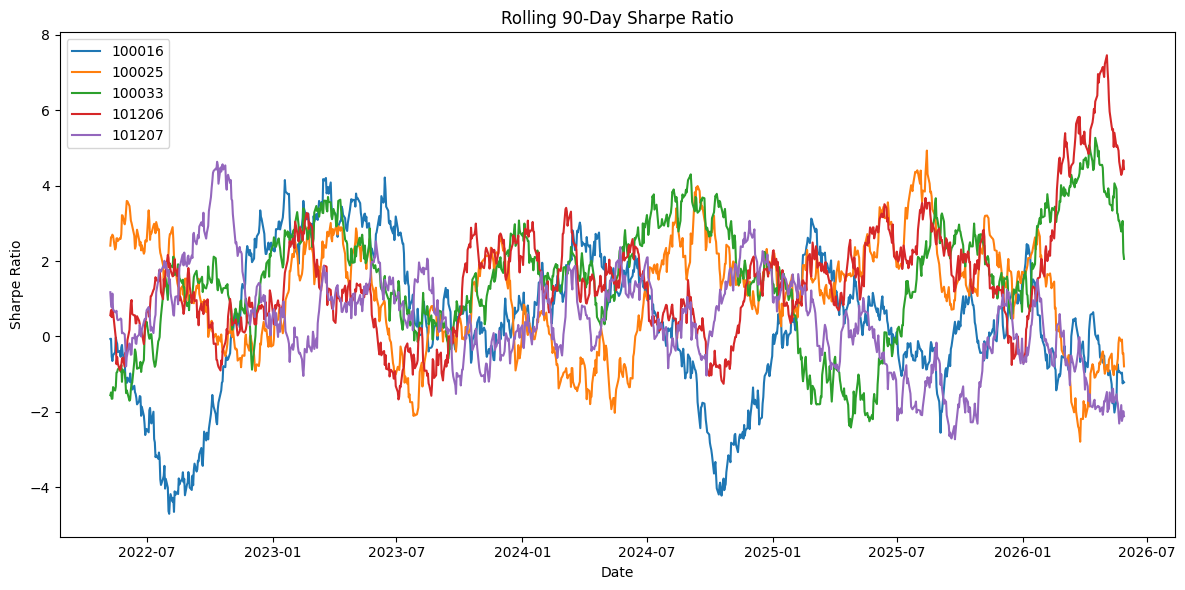

In [6]:
## Rolling 90-Day Sharpe Ratio
# Calculate rolling Sharpe for 5 funds

top_funds = nav_df['amfi_code'].unique()[:5]

plt.figure(figsize=(12,6))

for code in top_funds:

    fund = nav_df[nav_df['amfi_code'] == code].copy()

    returns = fund['daily_return']

    rolling_sharpe = (
        returns.rolling(90).mean()
        / returns.rolling(90).std()
    ) * np.sqrt(252)

    plt.plot(
        fund['date'],
        rolling_sharpe,
        label=str(code)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../data/processed/rolling_sharpe_chart.png"
)

plt.show()

In [7]:
## Investor Cohort Analysis
# Convert transaction date

txn_df['transaction_date'] = pd.to_datetime(txn_df['transaction_date'])

# First transaction year per investor

first_txn = (
    txn_df.groupby('investor_id')['transaction_date']
    .min()
    .dt.year
)

txn_df['cohort_year'] = txn_df['investor_id'].map(first_txn)

# Cohort metrics

cohort_summary = txn_df.groupby('cohort_year').agg(
    avg_investment=('amount_inr', 'mean'),
    total_invested=('amount_inr', 'sum')
).reset_index()

cohort_summary

,cohort_year,avg_investment,total_invested
0,2024,107422.541832,3491125187
1,2025,109158.577061,30455243


In [8]:
# Top fund preference by cohort

top_funds = (
    txn_df.groupby(['cohort_year', 'amfi_code'])
    .size()
    .reset_index(name='count')
)

top_fund_pref = (
    top_funds.sort_values(
        ['cohort_year', 'count'],
        ascending=[True, False]
    )
    .groupby('cohort_year')
    .first()
    .reset_index()
)

top_fund_pref

,cohort_year,amfi_code,count
0,2024,148568,874
1,2025,119599,12


In [9]:
## SIP Continuity Analysis
# SIP transactions only

sip_df = txn_df[
    txn_df['transaction_type'] == 'SIP'
].copy()

# Sort by investor and date

sip_df = sip_df.sort_values(
    ['investor_id', 'transaction_date']
)

# Calculate gap between SIP dates

sip_df['gap_days'] = (
    sip_df.groupby('investor_id')['transaction_date']
    .diff()
    .dt.days
)

# Investors with 6+ SIP transactions

sip_counts = (
    sip_df.groupby('investor_id')
    .size()
)

eligible = sip_counts[
    sip_counts >= 6
].index

sip_analysis = (
    sip_df[sip_df['investor_id'].isin(eligible)]
    .groupby('investor_id')
    .agg(avg_gap_days=('gap_days', 'mean'))
    .reset_index()
)

# At-risk flag

sip_analysis['status'] = np.where(
    sip_analysis['avg_gap_days'] > 35,
    'At Risk',
    'Active'
)

sip_analysis.head()

,investor_id,avg_gap_days,status


In [10]:
sip_counts.describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
dtype: float64

In [11]:
sip_counts.max()

nan

In [12]:
eligible = sip_counts[sip_counts >= 3].index

sip_analysis = (
    sip_df[sip_df['investor_id'].isin(eligible)]
    .groupby('investor_id')
    .agg(avg_gap_days=('gap_days', 'mean'))
    .reset_index()
)

sip_analysis['status'] = np.where(
    sip_analysis['avg_gap_days'] > 35,
    'At Risk',
    'Active'
)

sip_analysis.head()

,investor_id,avg_gap_days,status


In [13]:
txn_df['transaction_type'].value_counts(dropna=False)

transaction_type
Sip           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64

In [14]:
# SIP Continuity Analysis

sip_df = txn_df[
    txn_df['transaction_type'] == 'Sip'
].copy()

sip_df = sip_df.sort_values(
    ['investor_id', 'transaction_date']
)

sip_df['gap_days'] = (
    sip_df.groupby('investor_id')['transaction_date']
    .diff()
    .dt.days
)

sip_counts = sip_df.groupby('investor_id').size()

print("Maximum SIP transactions by one investor:")
print(sip_counts.max())

Maximum SIP transactions by one investor:
12


In [15]:
# Investors with 6+ SIP transactions

eligible = sip_counts[sip_counts >= 6].index

sip_analysis = (
    sip_df[sip_df['investor_id'].isin(eligible)]
    .groupby('investor_id')
    .agg(avg_gap_days=('gap_days', 'mean'))
    .reset_index()
)

sip_analysis['status'] = np.where(
    sip_analysis['avg_gap_days'] > 35,
    'At Risk',
    'Active'
)

sip_analysis.head()

,investor_id,avg_gap_days,status
0,INV000004,85.400000,At Risk
1,INV000008,70.400000,At Risk
2,INV000010,64.800000,At Risk
3,INV000011,40.166667,At Risk
4,INV000012,57.000000,At Risk


In [16]:
# Fund Recommender

risk_input = "Moderate"   # Change to Low / Moderate / High

recommendations = (
    perf_df[perf_df['risk_grade'] == risk_input]
    .sort_values('sharpe_ratio', ascending=False)
    .head(3)
)

recommendations[
    ['scheme_name', 'risk_grade', 'sharpe_ratio']
]

,scheme_name,risk_grade,sharpe_ratio
5,HDFC Top 100 Fund - Regular Plan - Growth,Moderate,1.06
34,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,Moderate,1.03


In [17]:
# Sector HHI Concentration

holdings_df['weight_pct'] = holdings_df['weight_pct'].astype(float)

hhi_df = (
    holdings_df.groupby('scheme_code')['weight_pct']
    .apply(lambda x: ((x/100) ** 2).sum())
    .reset_index(name='HHI')
)

hhi_df = hhi_df.sort_values('HHI', ascending=False)

hhi_df.head()

NameError: name 'holdings_df' is not defined

In [18]:
holdings_df = pd.read_csv(
    "../data/processed/cleaned_portfolio_holdings.csv"
)

holdings_df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/cleaned_portfolio_holdings.csv'

In [19]:
holdings_df = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

holdings_df.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [20]:
holdings_df.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')

In [21]:
# Sector HHI Concentration

holdings_df["weight_pct"] = holdings_df["weight_pct"].astype(float)

hhi_df = (
    holdings_df.groupby("amfi_code")["weight_pct"]
    .apply(lambda x: ((x / 100) ** 2).sum())
    .reset_index(name="sector_HHI")
)

hhi_df = hhi_df.sort_values(
    "sector_HHI",
    ascending=False
)

hhi_df.head()

,amfi_code,sector_HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298


In [22]:
hhi_df.to_csv(
    "../data/processed/sector_hhi_report.csv",
    index=False
)

print("sector_hhi_report.csv saved")

sector_hhi_report.csv saved


In [ ]:
# Advanced Insights

1. Funds with the highest VaR and CVaR values show greater downside risk during volatile market periods.
2. The 2024 investor cohort contributed the highest total investment amount.
3. Several investors with 6+ SIP transactions have average SIP gaps above 35 days and are classified as At Risk.
4. Moderate-risk funds such as HDFC Top 100 and Mirae Asset Large Cap showed strong Sharpe Ratio performance.
5. Funds with higher HHI values have more concentrated portfolios, meaning higher exposure to selected holdings.